In [70]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math

# import import_ipynb
from graph_functions import *
from iterative_pruning_func import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [71]:
def test_algorithem(G_):
    G = G_.copy()

    # start with a fully infected graph
    fully_infect(G)
    
    # 1. stage
    minimise_infection(G, 0)
    pc = calc_graph_values(G)
    print(pc)
    display_graph_stage(G)
    
    for iteration in range(100):
        if len(pc) == 0:
            break
        
        e = pc[0]
        G.nodes[pc[0]]["infected"] = False
        pc = calc_graph_values(G)
        
        H, infected_nodes, healthy_nodes = fully_endemic(G)
        if healthy_nodes:
            print("Graph healhy nodes ramaining ", healthy_nodes)
            print("FAIL")
        display_graph_stage(G, prism=True)

    # print("iterations: ", iteration)

    min_infection_number = 0
    for x in G.nodes():
        if G.nodes[x].get("infected"):
            min_infection_number += 1

    print("Minimal infection number: ", min_infection_number)
    return G, min_infection_number


def show_graphs(G):
    fig, axes = plt.subplots(2, 2, figsize=(6, 6))
    labels = {
        n: (G.nodes[n].get("infection_influence") if G.nodes[n].get("infected") else G.nodes[n].get("infection_count"))
        for n in G.nodes()
    }

    print(calc_graph_values(G))
    display_graph2(G, labels=labels, ax=axes[0, 0])
    display_graph2(G, labels=labels, pos=distance_partitions_pos(G, x_spacing=7.0, y_spacing=3.0), ax=axes[0, 1])

    H, min_infection_number = test_algorithem(G)
    print(calc_graph_values(H))

    display_graph2(H, labels=labels, ax=axes[1, 0])
    display_graph2(H, labels=labels, pos=distance_partitions_pos(G, x_spacing=7.0, y_spacing=3.0), ax=axes[1, 1])

    
    for ax in fig.get_axes():
        ax.label_outer()
    
    plt.tight_layout()
    plt.show()

0 {'infected': 0, 'infection_count': 9}
1 {'infected': 1}
2 {'infected': 1}
3 {'infected': 1}
4 {'infected': 1}
5 {'infected': 1}
6 {'infected': 1}
7 {'infected': 1}
8 {'infected': 1}
9 {'infected': 1}
0 {'infected': 0, 'infection_count': 9}
1 {'infected': 1, 'infection_influence': 1}
2 {'infected': 1, 'infection_influence': 1}
3 {'infected': 1, 'infection_influence': 1}
4 {'infected': 1, 'infection_influence': 1}
5 {'infected': 1, 'infection_influence': 1}
6 {'infected': 1, 'infection_influence': 1}
7 {'infected': 1, 'infection_influence': 1}
8 {'infected': 1, 'infection_influence': 1}
9 {'infected': 1, 'infection_influence': 1}
[]


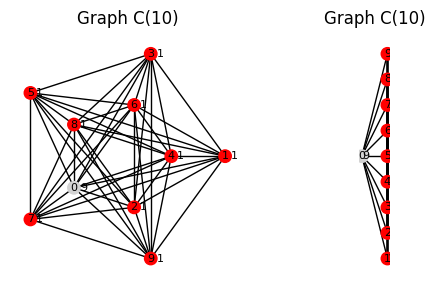

Minimal infection number:  9


(<networkx.classes.graph.Graph at 0x7fb56f84f730>, 9)

In [72]:
x = 10
test_algorithem(nx.complete_graph(x))

# show_graphs(nx.circular_ladder_graph(x))
# show_graphs(nx.balanced_tree(x, 4))
# show_graphs(nx.binomial_tree(5))
# show_graphs(nx.hypercube_graph(5))

# show_graphs(nx.pappus_graph())
# show_graphs(nx.star_graph(x))
# show_graphs(nx.star_graph(x))
# show_graphs(nx.star_graph(x))